# WeatherML - Data Exploration

Use this notebook for exploratory data analysis and experimentation.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sys, os

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))  # or "." depending on location

from scripts.fetch_data import fetch_data

latitude = 25.7617
longitude = 80.1918
df = fetch_data(latitude, longitude, start_date="2019-01-01", end_date="2023-12-31", save_csv=True, csv_path="../data/raw/daily_weather.csv")
df.head()

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,relative_humidity_2m_max,relative_humidity_2m_min,relative_humidity_2m_mean,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,shortwave_radiation_sum,sunshine_duration,weather_code,target
0,2019-01-01,21.8,6.5,14.3,20.9,4.3,94,39,68,4.9,11.4,307,0.0,0.0,0.0,0.0,13.81,35717.66,0,21.7
1,2019-01-02,22.6,8.0,14.6,21.7,6.0,95,41,71,6.4,9.8,43,0.0,0.0,0.0,0.0,13.72,35757.15,0,21.2
2,2019-01-03,22.6,7.8,14.6,21.2,6.2,97,41,73,6.5,13.4,292,0.0,0.0,0.0,0.0,13.86,35797.77,0,21.6
3,2019-01-04,22.2,8.0,14.7,21.6,6.1,96,35,69,5.8,10.3,327,0.0,0.0,0.0,0.0,13.65,33561.61,3,21.5
4,2019-01-05,23.4,9.9,16.0,21.5,8.2,86,42,66,7.9,16.6,85,0.0,0.0,0.0,0.0,13.27,33308.56,3,23.3


In [3]:
df.isna().sum()

time                           0
temperature_2m_max             0
temperature_2m_min             0
temperature_2m_mean            0
apparent_temperature_max       0
apparent_temperature_min       0
relative_humidity_2m_max       0
relative_humidity_2m_min       0
relative_humidity_2m_mean      0
wind_speed_10m_max             0
wind_gusts_10m_max             0
wind_direction_10m_dominant    0
precipitation_sum              0
rain_sum                       0
snowfall_sum                   0
precipitation_hours            0
shortwave_radiation_sum        0
sunshine_duration              0
weather_code                   0
target                         1
dtype: int64

In [4]:
# Find where the target variable is null
df[df["target"].isna()]

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,relative_humidity_2m_max,relative_humidity_2m_min,relative_humidity_2m_mean,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,shortwave_radiation_sum,sunshine_duration,weather_code,target
1825,2023-12-31,20.4,8.5,13.4,20.3,7.3,100,58,85,5.1,11.2,56,0.0,0.0,0.0,0.0,12.11,29391.33,3,NaN


12/31/23: Ignore (remove when processing data)

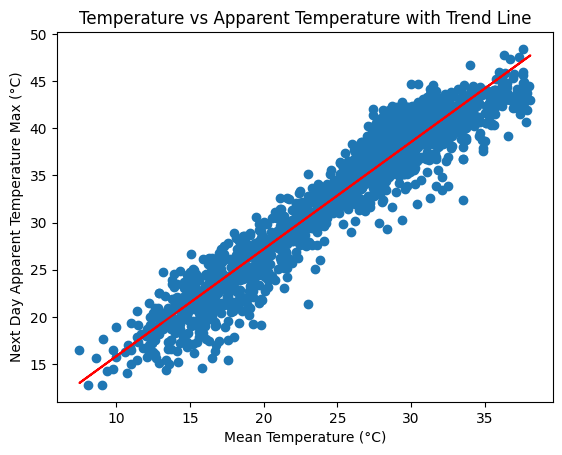

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = df["temperature_2m_mean"]
y = df["target"]

# Remove NaNs (important for polyfit)
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# Line of best fit
m, b = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + b, color='red')  # ← red trend line

plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Next Day Apparent Temperature Max (°C)")
plt.title("Temperature vs Apparent Temperature with Trend Line")

plt.show()

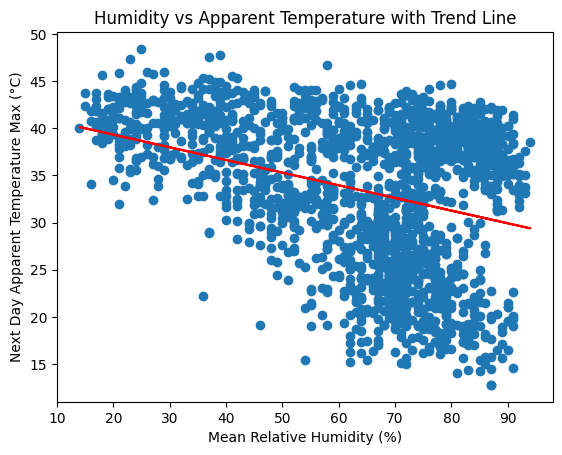

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = df["relative_humidity_2m_mean"]
y = df["target"]

# Remove NaNs
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# Line of best fit
m, b = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + b, color='red')

plt.xlabel("Mean Relative Humidity (%)")
plt.ylabel("Next Day Apparent Temperature Max (°C)")
plt.title("Humidity vs Apparent Temperature with Trend Line")

plt.show()

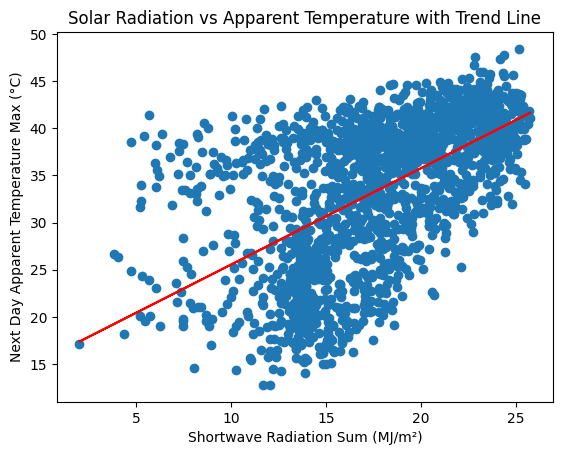

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x = df["shortwave_radiation_sum"]
y = df["target"]

# Remove NaNs
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# Line of best fit
m, b = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + b, color='red')

plt.xlabel("Shortwave Radiation Sum (MJ/m²)")
plt.ylabel("Next Day Apparent Temperature Max (°C)")
plt.title("Solar Radiation vs Apparent Temperature with Trend Line")

plt.show()

In [4]:
df = pd.read_csv("../data/raw/daily_weather.csv")
df.head()

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,relative_humidity_2m_max,relative_humidity_2m_min,relative_humidity_2m_mean,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,shortwave_radiation_sum,sunshine_duration,weather_code,target
0,2019-01-01,21.8,6.5,14.3,20.9,4.3,94,39,68,4.9,11.4,307,0.0,0.0,0.0,0.0,13.81,35717.66,0,21.7
1,2019-01-02,22.6,8.0,14.6,21.7,6.0,95,41,71,6.4,9.8,43,0.0,0.0,0.0,0.0,13.72,35757.15,0,21.2
2,2019-01-03,22.6,7.8,14.6,21.2,6.2,97,41,73,6.5,13.4,292,0.0,0.0,0.0,0.0,13.86,35797.77,0,21.6
3,2019-01-04,22.2,8.0,14.7,21.6,6.1,96,35,69,5.8,10.3,327,0.0,0.0,0.0,0.0,13.65,33561.61,3,21.5
4,2019-01-05,23.4,9.9,16.0,21.5,8.2,86,42,66,7.9,16.6,85,0.0,0.0,0.0,0.0,13.27,33308.56,3,23.3


In [ ]:
# Identify the data type for each column
print(df.dtypes)

time                            object
temperature_2m_max             float64
temperature_2m_min             float64
temperature_2m_mean            float64
apparent_temperature_max       float64
apparent_temperature_min       float64
relative_humidity_2m_max         int64
relative_humidity_2m_min         int64
relative_humidity_2m_mean        int64
wind_speed_10m_max             float64
wind_gusts_10m_max             float64
wind_direction_10m_dominant      int64
precipitation_sum              float64
rain_sum                       float64
snowfall_sum                   float64
precipitation_hours            float64
shortwave_radiation_sum        float64
sunshine_duration              float64
weather_code                     int64
target                         float64
dtype: object
